In [1]:
#######  V2 #############


import torch
import torch.nn as nn
import torch.nn.functional as F

from groupy.gconv.pytorch_gconv.splitgconv2d import P4ConvZ2, P4ConvP4
from groupy.gconv.pytorch_gconv import P4MConvZ2, P4MConvP4M
from groupy.gconv.pytorch_gconv.pooling import plane_group_spatial_max_pooling

class NNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(NNet, self).__init__()
        

        self.conv1 = P4MConvZ2(in_channels, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = P4MConvP4M(32, 32, kernel_size=3, stride=1, padding=1)

        self.conv3 = P4MConvP4M(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = P4MConvP4M(64, 128, kernel_size=3, stride=1, padding=1)

        self.conv5 = P4MConvP4M(128, 64, kernel_size=3, padding=1)
        self.conv6 = P4MConvP4M(64, 32, kernel_size=3, padding=1)

#         self.conv3 = P4MConvP4M(48, 96, kernel_size=3, stride=1, padding=1)
#         self.conv4 = P4MConvP4M(96, 192, kernel_size=3, stride=1, padding=1)

#         self.conv5 = P4MConvP4M(192, 96, kernel_size=3, padding=1)
#         self.conv6 = P4MConvP4M(96, 48, kernel_size=3, padding=1)
        self.convt = nn.ConvTranspose2d(32*8, out_channels, kernel_size=2, stride=2, output_padding=0)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = plane_group_spatial_max_pooling(x, 2, 2)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        xs = x.size()
        x = x.view(xs[0], xs[1] * xs[2], xs[3], xs[4])
#         x = F.avg_pool2d(x, 2, 2)
        x = self.convt(x)

        return x

In [2]:
model = NNet(1, 1).cuda()
model.load_state_dict(torch.load('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/NNet_groupy_p4m_v2_STED.pth'))

<All keys matched successfully>

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

from PIL import Image
from skimage import restoration
from skimage.filters import threshold_otsu
import copy
import matplotlib.pyplot as plt
# from model import NerdyNet
# from dataloader import ERDataset

import numpy as np

np.random.seed(34)
torch.manual_seed(34)

figdata = []


for i in range(40, 45):
#     imgpath = f'/localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t0{i:02d}_ch00_std.png'
    imgpath = f'/localhome/asa420/MIAL/data/sted-data/Climp/std/C1_decon_t0{i:02d}_ch00_std.png'

    image = Image.open(imgpath)
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    image = transform(image)
    image = image.unsqueeze(0)  # Add batch dimension

    # Forward pass through the model
    model.eval()
    with torch.no_grad():
        output = model(image.cuda())

    # Convert the output to probabilities by applying the sigmoid activation
    output_probs = torch.sigmoid(output)

    # Convert tensors to numpy arrays for visualization
    image_np = image.squeeze().numpy()
    output_probs_np = output_probs.cpu().squeeze().numpy()

    norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

    rb = restoration.rolling_ball(norm)
    subt = norm - rb

    thr = threshold_otsu(subt)

    subt2 = copy.deepcopy(subt)

    subt2[subt < thr] = 0.
    subt2[subt >= thr] = 255.
    
#     plt.imshow(subt2)
    figdata.append(subt2)


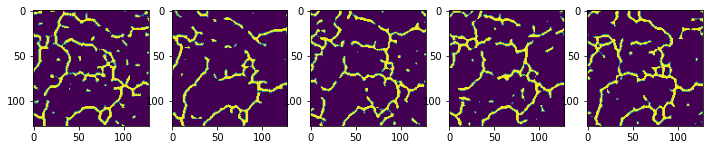

In [6]:
plt.figure(figsize=(12, 12))

plt.subplot(151)
plt.imshow(figdata[0])

plt.subplot(152)
plt.imshow(figdata[1])
plt.subplot(153)
plt.imshow(figdata[2])
plt.subplot(154)
plt.imshow(figdata[3])
plt.subplot(155)
plt.imshow(figdata[4])

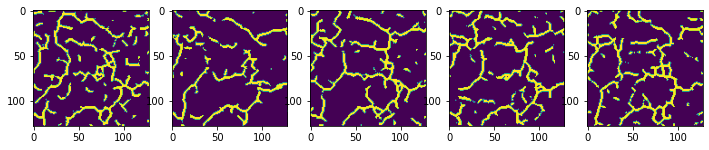

In [9]:
plt.figure(figsize=(12, 12))

plt.subplot(151)
plt.imshow(figdata[0])

plt.subplot(152)
plt.imshow(figdata[1])
plt.subplot(153)
plt.imshow(figdata[2])
plt.subplot(154)
plt.imshow(figdata[3])
plt.subplot(155)
plt.imshow(figdata[4])

In [51]:
model = NNet(2, 1).cuda()
model.load_state_dict(torch.load('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/NNet_groupy_p4m_v2_STED_noise.pth'))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

from PIL import Image
from skimage import restoration
from skimage.filters import threshold_otsu
import copy
import matplotlib.pyplot as plt
# from model import NerdyNet
# from dataloader import ERDataset

import numpy as np

np.random.seed(34)
torch.manual_seed(34)

figdata = []


for i in range(5, 10):
#     imgpath = f'/localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t0{i:02d}_ch00_std.png'
    imgpath = f'/localhome/asa420/MIAL/data/sted-data/Climp/std/C1_decon_t0{i:02d}_ch00_std.png'

    image = imageio.imread(imgpath)
    noisy_image = skimage.util.random_noise(image)
    image = np.stack((image, noisy_image),axis=2)
    image = image.astype('float32')
#     image = Image.open(imgpath)
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    image = transform(image)
    image = image.unsqueeze(0)  # Add batch dimension

    # Forward pass through the model
    model.eval()
    with torch.no_grad():
        output = model(image.cuda())

    # Convert the output to probabilities by applying the sigmoid activation
    output_probs = torch.sigmoid(output)

    # Convert tensors to numpy arrays for visualization
    image_np = image.squeeze().numpy()
    output_probs_np = output_probs.cpu().squeeze().numpy()

    norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

    rb = restoration.rolling_ball(norm)
    subt = norm - rb

    thr = threshold_otsu(subt)

    subt2 = copy.deepcopy(subt)

    subt2[subt < thr] = 0.
    subt2[subt >= thr] = 255.
    
#     plt.imshow(subt2)
    figdata.append(subt2)



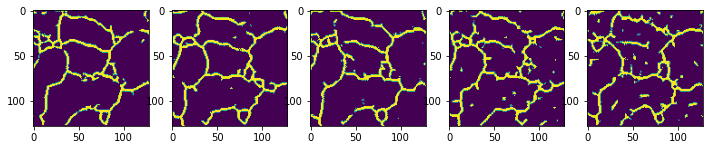

In [52]:
plt.figure(figsize=(12, 12))

plt.subplot(151)
plt.imshow(figdata[0])

plt.subplot(152)
plt.imshow(figdata[1])
plt.subplot(153)
plt.imshow(figdata[2])
plt.subplot(154)
plt.imshow(figdata[3])
plt.subplot(155)
plt.imshow(figdata[4])

In [10]:
import imageio
img = imageio.imread('/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/climp/masks/sted_climp3_er_mean_mask.png')
np.unique(img)

Array([  0, 255], dtype=uint8)

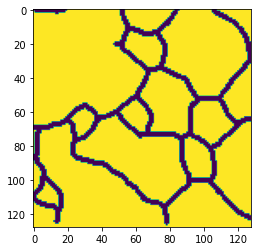

In [11]:
import copy
nimg = copy.deepcopy(img)

nimg[img==0] = 100
nimg[img==255] = 0
nimg[nimg==100] = 255

plt.imshow(nimg)

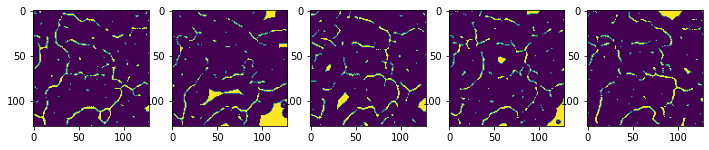

In [17]:
plt.figure(figsize=(12, 12))

plt.subplot(151)
plt.imshow(figdata[0])

plt.subplot(152)
plt.imshow(figdata[1])
plt.subplot(153)
plt.imshow(figdata[2])
plt.subplot(154)
plt.imshow(figdata[3])
plt.subplot(155)
plt.imshow(figdata[4])

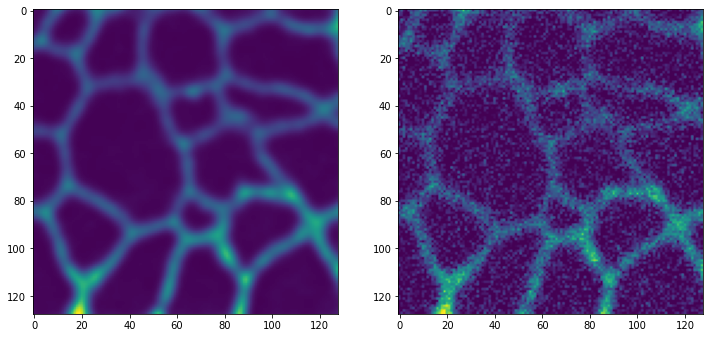

In [44]:
import skimage

img = imageio.imread('/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/climp/images/sted_climp4_er_mean.png')

# gau_img = skimage.filters.gaussian(img, sigma=10, truncate=1/5)

nimg = skimage.util.random_noise(img, 'localvar')

plt.figure(figsize=(12, 12))

plt.subplot(121)
plt.imshow(img)

plt.subplot(122)
plt.imshow(nimg)

In [ ]:
masks = '/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/rtn/masks/'



In [60]:
import sknw

atl1 = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/skel/atl1_proc_skel.png')
graph = sknw.build_sknw(atl1, multi=False, iso=False)

In [108]:
import networkx as nx

# data = nx.cycle_basis(graph.to_undirected())
data = nx.minimum_cycle_basis(graph.to_undirected(), weight=None)

In [96]:
grun = graph.to_undirected()

grun[0]

AtlasView({15: {'pts': array([[ 0, 42],
       [ 1, 42],
       [ 2, 41],
       [ 3, 41],
       [ 4, 41],
       [ 5, 40],
       [ 6, 40],
       [ 7, 40],
       [ 8, 39],
       [ 9, 39],
       [10, 38],
       [11, 38],
       [12, 37],
       [13, 37],
       [14, 37],
       [16, 37]], dtype=int16), 'weight': 18.071067811865476}})

In [106]:
gnx = nx.Graph()

gnx.add_edges_from(graph.edges(data=True))#, weight=None)
gnx.add_nodes_from(graph.nodes(data=True))#, weight=None)

In [107]:
gnx[0]

AtlasView({15: {'pts': array([[ 0, 42],
       [ 1, 42],
       [ 2, 41],
       [ 3, 41],
       [ 4, 41],
       [ 5, 40],
       [ 6, 40],
       [ 7, 40],
       [ 8, 39],
       [ 9, 39],
       [10, 38],
       [11, 38],
       [12, 37],
       [13, 37],
       [14, 37],
       [16, 37]], dtype=int16), 'weight': 18.071067811865476}})

In [109]:
c1 = data[0]

In [110]:
c1

[4, 7, 8, 12]

In [111]:
node_set, degree_list = graph.nodes, graph.degree

In [112]:
node_set[3]

{'pts': array([[  1, 118]], dtype=int16), 'o': array([  1, 118], dtype=uint16)}

In [113]:
node_coords = np.array([node_set[node]['o'] for node in node_set])

In [114]:
node_coords[c1[0]]

array([ 3, 79], dtype=uint16)

In [137]:
lt = [node_coords[node] for node in cycle]
lt

[array([125,  65], dtype=uint16),
 array([107,  56], dtype=uint16),
 array([109,  59], dtype=uint16),
 array([110,  44], dtype=uint16),
 array([114,  43], dtype=uint16),
 array([117,  64], dtype=uint16),
 array([119,  43], dtype=uint16),
 array([122,  47], dtype=uint16)]

In [138]:
import math

def calculate_angle(point, reference_point):
    x, y = point[0] - reference_point[0], point[1] - reference_point[1]
    return math.atan2(y, x)

def sort_points_clockwise(points):
    # Find the centroid as the reference point
    reference_point = [sum(x[0] for x in points) / len(points),
                       sum(x[1] for x in points) / len(points)]

    # Sort the points based on the angle with respect to the reference point
    sorted_points = sorted(points, key=lambda p: calculate_angle(p, reference_point))

    return sorted_points


[array([110,  44], dtype=uint16), array([114,  43], dtype=uint16), array([119,  43], dtype=uint16), array([122,  47], dtype=uint16), array([125,  65], dtype=uint16), array([117,  64], dtype=uint16), array([109,  59], dtype=uint16), array([107,  56], dtype=uint16)]


In [152]:
from shapely.geometry import Polygon


# node_coords = sort_points_clockwise(node_coords)


for idx, cycle in enumerate(data):
    sorted_points = sort_points_clockwise(node_coords[cycle])

    xl = [point[0] for point in sorted_points]
    yl = [point[1] for point in sorted_points]
    
    if len(xl) > 3:
        polygon = Polygon(zip(xl, yl))
        print(polygon.area)


48.0
160.5
158.0
55.5
107.5
51.0
68.0
39.0
114.5
76.0
111.0
14.0
73.0
211.0
139.0
73.5
95.0
388.0
455.0
77.0
87.5
55.0
36.0
398.5
75.0
121.5
124.5
74.0
31.0
60.0
220.0
89.5
174.0
60.0
288.5
652.5
92.5
246.0
41.5
60.0
205.0
110.0
438.0
61.0
65.5
129.5
90.0
90.0
58.0
19.0
27.0
86.5
38.0
282.5
73.5
65.5
133.0
39.0
36.5
126.0
77.0
139.5
85.0
382.5
145.0
278.5
176.5
281.0


In [82]:
xl

[40, 47, 46, 39]

In [83]:
yl

[67, 65, 60, 56]

In [84]:

pgon = Polygon(zip(xl, yl))

pgon.area

55.0

In [136]:
def PolyArea(x,y):
    return 0.5*np.abs(np.dot(x,np.roll(y,1))-np.dot(y,np.roll(x,1)))

# a = [3, 5, 6, 11]
# b = [79, 71, 83, 79]

a = [5, 11, 6, 3] 
b = [71, 79, 83, 79]

PolyArea(a, b)

48.0

In [129]:
import numpy as np
from scipy.spatial import ConvexHull

# set up example
np.random.seed(0)
# pts = np.random.multivariate_normal(np.zeros(2), np.identity(2), size=12)

pts = [[3, 79], [5, 71], [6, 83], [11, 79]]



[[3, 79], [5, 71], [6, 83], [11, 79]]

Original Points: [[3, 79], [5, 71], [6, 83], [11, 79]]
Sorted Points Clockwise: [[5, 71], [11, 79], [6, 83], [3, 79]]


TypeError: list indices must be integers or slices, not tuple

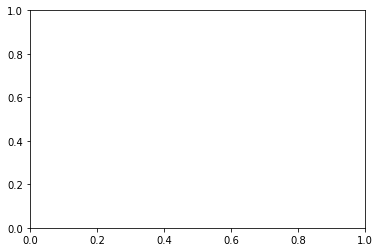

In [134]:
import numpy as np
from scipy.spatial import ConvexHull
import math

# set up example
# np.random.seed(0)
# pts = np.random.multivariate_normal(np.zeros(2), np.identity(2), size=100)
# verts = np.array([[3, 79], [5, 71], [6, 83], [11, 79]])



# hull = ConvexHull(pts)

# vertices of a randomly generated
# convex polygon in R2
# verts = hull.points[hull.vertices]

# print(verts)

# # # shuffle vertices
# # np.random.shuffle(verts)

# # get complex numbers
# zs = verts[:,0] + 1j * verts[:,1]
# verts_sorted = verts[np.angle(zs).argsort()]

import math

def calculate_angle(point, reference_point):
    x, y = point[0] - reference_point[0], point[1] - reference_point[1]
    return math.atan2(y, x)

def sort_points_clockwise(points):
    # Find the centroid as the reference point
    reference_point = [sum(x[0] for x in points) / len(points),
                       sum(x[1] for x in points) / len(points)]

    # Sort the points based on the angle with respect to the reference point
    sorted_points = sorted(points, key=lambda p: calculate_angle(p, reference_point))

    return sorted_points

# Example set of points
points = [[3, 79], [5, 71], [6, 83], [11, 79]]

# Sort the points clockwise
sorted_points = sort_points_clockwise(points)

verts_sorted = sorted_points

print("Original Points:", points)
print("Sorted Points Clockwise:", sorted_points)


# plot
from matplotlib import pyplot as plt

fig, ax = plt.subplots()
ax.scatter(verts_sorted[:,0], verts_sorted[:,1])

for i, p in enumerate(verts_sorted):
    ax.annotate(str(i), (p[0], p[1]))

# plt.savefig("verts_sorted.png")
plt.show()

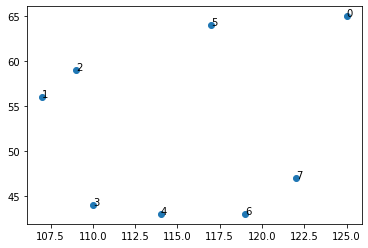

In [140]:
import numpy as np
from scipy.spatial import ConvexHull

# set up example
np.random.seed(0)
# pts = np.random.multivariate_normal(np.zeros(2), np.identity(2), size=100)
# hull = ConvexHull(pts)

# # vertices of a randomly generated
# # convex polygon in R2
# verts = hull.points[hull.vertices]

# verts = np.array([[3, 79], [5, 71], [6, 83], [11, 79]])

verts_sorted = np.array([[125,  65], [107,  56], [109,  59], [110,  44], [114,  43], [117,  64], [119,  43], [122,  47]])

# shuffle vertices
# np.random.shuffle(verts)

# get complex numbers
# zs = verts[:,0] + 1j * verts[:,1]
# verts_sorted = verts[np.angle(zs).argsort()]

# plot
from matplotlib import pyplot as plt

fig, ax = plt.subplots()
ax.scatter(verts_sorted[:,0], verts_sorted[:,1])

for i, p in enumerate(verts_sorted):
    ax.annotate(str(i), (p[0], p[1]))

# plt.savefig("verts_sorted.png")
plt.show()

[[110,  44] [114,  43] [119,  43] [122,  47] [125,  65] [117,  64] [109,  59] [107,  56]]

In [180]:


import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

from groupy.gconv.pytorch_gconv.splitgconv2d import P4ConvZ2, P4ConvP4
from groupy.gconv.pytorch_gconv import P4MConvZ2, P4MConvP4M
from groupy.gconv.pytorch_gconv.pooling import plane_group_spatial_max_pooling

from skimage.filters import threshold_minimum, threshold_mean

class NNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(NNet, self).__init__()
        

        self.conv1 = P4MConvZ2(in_channels, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = P4MConvP4M(32, 32, kernel_size=3, stride=1, padding=1)

        self.conv3 = P4MConvP4M(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = P4MConvP4M(64, 128, kernel_size=3, stride=1, padding=1)

        self.conv5 = P4MConvP4M(128, 64, kernel_size=3, padding=1)
        self.conv6 = P4MConvP4M(64, 32, kernel_size=3, padding=1)

        self.convt = nn.ConvTranspose2d(32*8, out_channels, kernel_size=2, stride=2, output_padding=0)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = plane_group_spatial_max_pooling(x, 2, 2)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        xs = x.size()
        x = x.view(xs[0], xs[1] * xs[2], xs[3], xs[4])
#         x = F.avg_pool2d(x, 2, 2)
        x = self.convt(x)

        return x


def load_models():
    p4m = NNet(1, 1)
    p4m.load_state_dict(torch.load('NNet_groupy_p4m_v2_VecAdam.pth'))

#     p4m_adaptive = NNet(1, 1)
#     p4m_adaptive.load_state_dict(torch.load('NNet_groupy_p4m_v2_VecAdam_adaptive.pth'))

    return p4m



def process_op(imgpath, model):
    image = Image.open(imgpath)
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    image = transform(image)
    image = image.unsqueeze(0)  # Add batch dimension

    model.eval()
    with torch.no_grad():
        output = model(image)

    # Convert the output to probabilities by applying the sigmoid activation
    output_probs = torch.sigmoid(output)

    # Convert tensors to numpy arrays for visualization
    output_probs_np = output_probs.cpu().squeeze().numpy()

    norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

    rb = restoration.rolling_ball(norm)
    subt = norm - rb

#     thr = threshold_otsu(subt)
#     thr = threshold_minimum(subt)
    thr = threshold_mean(subt)

    subt2 = copy.deepcopy(subt)

    subt2[subt < thr] = 0.
    subt2[subt >= thr] = 255.

    return subt2

In [181]:
from skimage.morphology import skeletonize
import skimage.io as io

model = load_models()

for seq in range(1, 32):
    for frame in range(100):
        imgpath = f'/localhome/asa420/MIAL/data/confocal-data/Climp/std/C{seq}_decon_t0{frame:02d}_ch00_std.png'
        op = process_op(imgpath, model) / 255
        skel = (skeletonize(op) * 255).astype('uint8')
        io.imsave(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/climp/skel/C{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)

In [182]:
for seq in range(1, 32):
    for frame in range(100):
        imgpath = f'/localhome/asa420/MIAL/data/confocal-data/Control/std/Ct{seq}_decon_t0{frame:02d}_ch00_std.png'
        op = process_op(imgpath, model) / 255
        skel = (skeletonize(op) * 255).astype('uint8')
        io.imsave(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/control/skel/Ct{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)
        
for seq in range(1, 27):
    for frame in range(100):
        imgpath = f'/localhome/asa420/MIAL/data/confocal-data/ATL/std/A{seq}_decon_t0{frame:02d}_ch00_std.png'
        op = process_op(imgpath, model) / 255
        skel = (skeletonize(op) * 255).astype('uint8')
        io.imsave(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/skel/A{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)

for seq in range(1, 30):
    for frame in range(100):
        imgpath = f'/localhome/asa420/MIAL/data/confocal-data/RTN/std/R{seq}_decon_t0{frame:02d}_ch00_std.png'
        op = process_op(imgpath, model) / 255
        skel = (skeletonize(op) * 255).astype('uint8')
        io.imsave(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/rtn/skel/R{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)


In [172]:
img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/gt_skel/atl2_proc_skel_new.png')
img[img != 255.] = 0

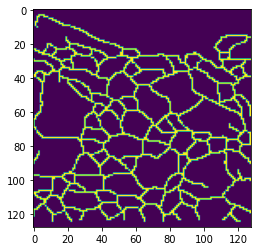

In [173]:
plt.imshow(img)

In [174]:
imageio.imsave('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/gt_skel/atl2_proc_skel_new.png', img)

In [188]:
for i in range(1, 17):
    try:
        analyzer_op = imageio.imread(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/climp/analyzer_op/ER_ce{i}.png')
        data = analyzer_op[:,:,0]
        data = data[52:1670, 52:1670]
        data = skimage.transform.resize(data, (128, 128), anti_aliasing=True)
        thr = threshold_otsu(data)
        bin_out = data > thr
        bin_out = bin_out.astype('uint8')*255
        imageio.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/climp/analyzer_op/resized_op/climp{i}_out.png', bin_out)
    except:
        pass